# Bifurcacion de Tridente Supercritica (Supercritical pitchfork)

Su forma normal es $\dot x = rx - x^3$

Buscando sus puntos de equilibrio, tenemos que: 

$$0 = rx^* - {x^*}^3 = x^*(r - {x^*}^2)$$

y esto nos dice que $x^{*} = 0$ siempre es punto de equilibrio

Ahora, notemos que:

si $r > 0$, $(r - {x^*}^2)=0$ tiene 2 soluciones por lo que, hay 3 soluciones de equilibrio, a saber, $x_1^*=0$, $x_{2,3}^*=\pm \sqrt{r}$ pero,

Si $r\leq 0$, solo tenemos una solucion de equilibrio que es $x^*=0$

Veamos ahora como son las estabilidades de estos puntos

como $f(x) = rx - x^3$, entonces $f'(x) = r - 3x^2$ de donde,

-$f'(0) = r$ por lo que:

$x^{*} = 0$ es **estable** si $r < 0$ y es **inestable** si $r > 0$, pero en $r = 0$ no nos dice nada

por otro lado:

$f'(\sqrt{r}) = -2r$, pero tambien $f'(-\sqrt{r}) = -2r$, por lo tanto, esto nos dice que $x_2^{*}$ y $x_3^{*}$ son estables cuando $r > 0$ pero $x^{*} = 0$ es inestable 

 Asi, este analisis nos dice que para $r \leq 0$ solo hay un punto de equilibrio que es $x^{*} = 0$ y es estable pero para $r > 0$ ya tenemos 3 puntos de equilibrio, que ademas ahora $x_1^{*} = 0$ es inestable y $x_1^{*} = \sqrt{r}$ y $x_2^{*} = -\sqrt{r}$ son estables 

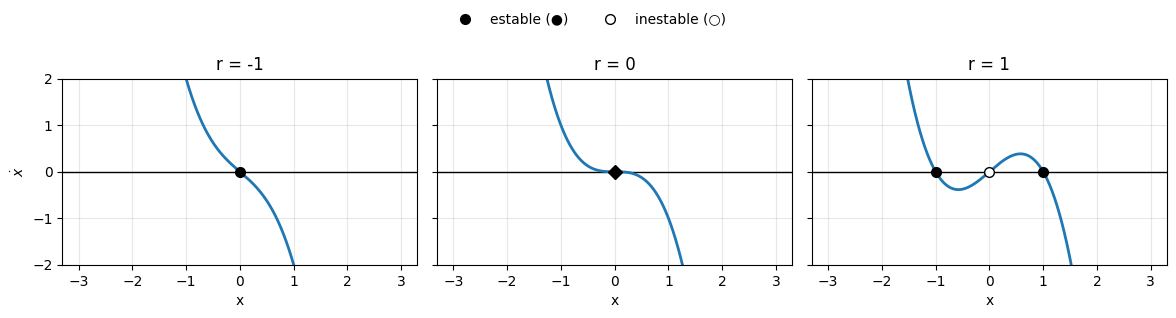

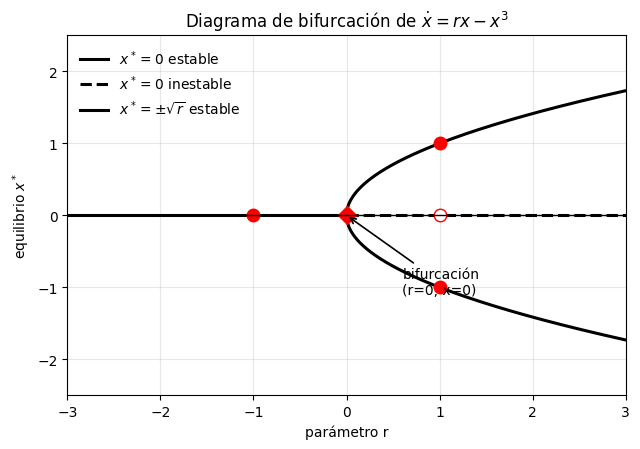

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Sistema: xdot = r x - x^3 ----
def f(x, r):
    return r*x - x**3

def fp(x, r):
    return r - 3*x**2

def equilibria(r):
    eq = [0.0]
    if r > 0:
        a = np.sqrt(r)
        eq += [-a, a]
    return sorted(eq)

# ---------- FIGURA 1: 3 graficas xdot vs x ----------
def plot_tres_graficas(rs=(-1, 0, 1), xlim=3.0, ylim_dx=(-2, 2), tol=1e-10):
    x = np.linspace(-xlim, xlim, 800)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)

    handles = {"estable": None, "inestable": None, "nohip": None}

    for ax, r in zip(axes, rs):
        ax.axhline(0, color="k", lw=1)
        ax.plot(x, f(x, r), lw=2)

        for xe in equilibria(r):
            d = fp(xe, r)
            if abs(d) < tol:
                h = ax.plot([xe], [0], marker="D", ms=7, linestyle="None", color="k")[0]
                if handles["nohip"] is None: handles["nohip"] = h
            elif d < 0:  # estable
                h = ax.plot([xe], [0], marker="o", ms=7, linestyle="None",
                            markerfacecolor="k", markeredgecolor="k")[0]
                if handles["estable"] is None: handles["estable"] = h
            else:        # inestable
                h = ax.plot([xe], [0], marker="o", ms=7, linestyle="None",
                            markerfacecolor="white", markeredgecolor="k")[0]
                if handles["inestable"] is None: handles["inestable"] = h

        ax.set_title(f"r = {r}")
        ax.set_xlabel("x")
        ax.set_ylim(*ylim_dx)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$\dot x$")

    fig.legend([handles["estable"], handles["inestable"]],
               ["estable (●)", "inestable (○)"],
               loc="upper center", ncol=3, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    return fig

# ---------- FIGURA 2: diagrama de bifurcacion ----------
def plot_diagrama_bifurcacion(rs=(-1, 0, 1), r_min=-3.0, r_max=3.0, tol=1e-10):
    r_neg = np.linspace(r_min, 0, 800)   # r<0
    r_pos = np.linspace(0, r_max, 800)   # r>0

    fig, ax = plt.subplots(figsize=(6.5, 4.6))

    # Rama x*=0: estable si r<0, inestable si r>0
    ax.plot(r_neg, 0*r_neg, "k-",  lw=2.2, label=r"$x^*=0$ estable")
    ax.plot(r_pos, 0*r_pos, "k--", lw=2.2, label=r"$x^*=0$ inestable")

    # Ramas x*=±sqrt(r) para r>0 (estables)
    xb = np.sqrt(r_pos)
    ax.plot(r_pos,  xb, "k-", lw=2.2, label=r"$x^*=\pm\sqrt{r}$ estable")
    ax.plot(r_pos, -xb, "k-", lw=2.2)

    # Punto no hiperbólico (0,0)
    ax.plot([0], [0], marker="D", ms=8, linestyle="None", color="k")
    ax.annotate("bifurcación\n(r=0, x=0)", xy=(0, 0), xytext=(0.6, -1.1),
                arrowprops=dict(arrowstyle="->", lw=1.2))

    # Marcar r=-1,0,1 en rojo con estabilidad
    for r in rs:
        for xe in equilibria(r):
            d = fp(xe, r)
            if abs(d) < tol:
                ax.plot([r], [xe], marker="D", ms=9, linestyle="None", color="red")
            elif d < 0:
                ax.plot([r], [xe], marker="o", ms=9, linestyle="None",
                        markerfacecolor="red", markeredgecolor="red")
            else:
                ax.plot([r], [xe], marker="o", ms=9, linestyle="None",
                        markerfacecolor="white", markeredgecolor="red")

    ax.axhline(0, color="k", lw=1)
    ax.set_xlim(r_min, r_max)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel("parámetro r")
    ax.set_ylabel(r"equilibrio $x^*$")
    ax.set_title(r"Diagrama de bifurcación de $\dot x = r x - x^3$")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    return fig

# --- Llamadas (2 figuras separadas) ---
plot_tres_graficas();
plot_diagrama_bifurcacion();
